# Model development (hybrid XGBoost)

Run after **feature extraction** and **data splitting**. This notebook trains **one** detector: XGBoost on late-fusion **H** (spaCy stats glued to ELECTRA meaning). It does not rebuild **S** or **E**, and it does not train the spaCy-only, ELECTRA-only, or TF-IDF baselines.

| Stage | Data | What happens |
|-------|------|----------------|
| Train | 70% of **H** | Grid search + 5-fold CV, then refit the winner on all train rows |
| Validation | 15% | Confirmation check only — no refit |
| Test | 15% | Final metrics, scored once |

After training, run **Metrics and fit diagnosis** for the table, overfit/underfit sentence, and charts.

Split indices stay in `data/processed/splits/`. The saved model lands in `data/processed/models/`.

In [20]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Re-run this cell after editing src/utils so Jupyter does not keep old modules.
for _name in list(sys.modules):
    if _name == "utils" or _name.startswith("utils."):
        del sys.modules[_name]

DATA_DIR = PROJECT_ROOT / "data"
COMBINED_CSV = DATA_DIR / "processed" / "combined_dataset.csv"
FEATURES_DIR = DATA_DIR / "processed" / "features"
SPLITS_DIR = DATA_DIR / "processed" / "splits"
MODELS_DIR = DATA_DIR / "processed" / "models"
HYBRID_NPY = FEATURES_DIR / "hybrid_features.npy"

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Combined CSV exists:", COMBINED_CSV.exists())
print("Hybrid H exists:", HYBRID_NPY.exists())

PROJECT_ROOT: /workspace/hybrid-ai-framework
Combined CSV exists: True
Hybrid H exists: True


**GPU SMOKE TEST**

In [21]:
import torch
from utils.features.split_and_train import smoke_test_xgboost_cuda

print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
smoke_test_xgboost_cuda(RANDOM_STATE)
print("XGBoost GPU smoke test OK")

CUDA: True NVIDIA GeForce RTX 4090
XGBoost GPU smoke test OK


## Load labels, split indices, and **H**

Row order must match `combined_dataset.csv` and the feature files. Training only sees the 70% train rows.

In [22]:
from utils.features.data_splitting import load_split_indices

if not COMBINED_CSV.exists():
    raise FileNotFoundError(f"Run data_cleaning.ipynb first: {COMBINED_CSV}")
if not HYBRID_NPY.exists():
    raise FileNotFoundError(f"Run feature_extraction.ipynb first: {HYBRID_NPY}")

df = pd.read_csv(COMBINED_CSV)
y = df["label"].to_numpy(dtype=np.int64)
H = np.load(HYBRID_NPY)
idx_train, idx_val, idx_test = load_split_indices(SPLITS_DIR)

n_rows = len(df)
if H.shape[0] != n_rows:
    raise ValueError(f"H has {H.shape[0]} rows, combined table has {n_rows}")
all_idx = np.concatenate([idx_train, idx_val, idx_test])
if len(all_idx) != n_rows or len(np.unique(all_idx)) != n_rows:
    raise ValueError("Split indices must be disjoint and cover every row of H.")

print("Rows:", n_rows, "H shape:", H.shape)
print("Train / val / test:", len(idx_train), len(idx_val), len(idx_test))

Rows: 157004 H shape: (157004, 778)
Train / val / test: 109902 23551 23551


## Train on 70% of **H**

Training rows are fit only. Each setting can grow up to 400 trees and **stops on the validation slice** when logloss stalls. The winner is the one with the best validation **ROC-AUC minus FPR**. Leaves must cover more essays, extra splits are penalized, and the AI class is not down-weighted. If a depth-1 model is within half a point of false-positive rate, that smaller model is kept. The test slice is not used here.

When training finishes, run the **next** cell for metrics, fit diagnosis, and plots.

In [23]:
from utils.features.split_and_train import save_hybrid_model, train_xgboost_gpu

hybrid_model, search = train_xgboost_gpu(
    H[idx_train],
    y[idx_train],
    x_val=H[idx_val],
    y_val=y[idx_val],
    random_state=RANDOM_STATE,
    use_cuda=True,
)
print("XGBoost device:", hybrid_model.get_params().get("device"))
print("Best params:", search.best_params_)
print("Best validation score (ROC-AUC - FPR):", float(search.best_score_))
print("Trees kept:", search.best_iteration_)
print(search.selection_note_)

rank_cols = [c for c in search.cv_results_ if c.startswith("param_")] + [
    c for c in ("mean_test_score", "val_fpr", "best_iteration") if c in search.cv_results_
]
cv_rank = pd.DataFrame(search.cv_results_)[rank_cols].sort_values(
    "mean_test_score", ascending=False
)
display(cv_rank.head(8))

cv_results = {
    "hybrid": {
        "best_params": search.best_params_,
        "best_validation_score_auc_minus_fpr": float(search.best_score_),
        "trees_kept": int(search.best_iteration_),
        "selection_note": search.selection_note_,
        "device": hybrid_model.get_params().get("device"),
        "top_configs": cv_rank.head(8).to_dict(orient="records"),
    }
}
save_hybrid_model(MODELS_DIR, hybrid_model, cv_results=cv_results)
print("Saved hybrid model to", MODELS_DIR)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


XGBoost device: cuda
Best params: {'learning_rate': 0.1, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 400, 'scale_pos_weight': 0.11391960404099967, 'subsample': 0.8}
Best CV score (ROC-AUC - FPR): 0.9835995748798064


,param_learning_rate,param_max_depth,param_min_child_weight,param_n_estimators,param_scale_pos_weight,param_subsample,mean_test_score,std_test_score
38,0.10,2,1,400,0.11392,0.8,0.983600,0.009746
39,0.10,2,1,400,0.11392,1.0,0.981473,0.009958
54,0.10,3,1,400,0.11392,0.8,0.981469,0.008877
35,0.10,2,1,200,0.11392,1.0,0.980754,0.010974
6,0.05,2,1,400,0.11392,0.8,0.980751,0.008333
34,0.10,2,1,200,0.11392,0.8,0.980751,0.006648
7,0.05,2,1,400,0.11392,1.0,0.980042,0.009211
22,0.05,3,1,400,0.11392,0.8,0.980033,0.010510


Saved hybrid model to /workspace/hybrid-ai-framework/data/processed/models


## Validation (15%) — confirmation only

We score the saved hybrid here to see if it looks sane. These numbers are **not** the final result, and we do not refit.

In [24]:
from utils.features.evaluate import classification_report_row

val_prob = hybrid_model.predict_proba(H[idx_val])[:, 1]
val_metrics = classification_report_row(y[idx_val], val_prob)
print("Validation (confirmation, not final):")
display(pd.DataFrame([val_metrics], index=["hybrid"]))

Validation (confirmation, not final):


,accuracy,precision,recall,f1,roc_auc,fpr,tn,fp,fn,tp
hybrid,0.999618,0.999699,0.999914,0.999806,0.999922,0.023179,295,7,2,23247


## Test (15%) — final metrics

One pass on the held-out test rows. No extra grid search, no refit.

In [25]:
test_prob = hybrid_model.predict_proba(H[idx_test])[:, 1]
test_metrics = classification_report_row(y[idx_test], test_prob)
print("Test (final):")
display(pd.DataFrame([test_metrics], index=["hybrid"]))

Test (final):


,accuracy,precision,recall,f1,roc_auc,fpr,tn,fp,fn,tp
hybrid,0.999788,0.999785,1.0,0.999892,0.999994,0.016556,297,5,0,23249


## Fit check (train vs validation vs test)

Same model, three slices. If train looks perfect but validation FPR jumps, it overfit the human essays. If all three are weak, it underfit. If they stay close, the fit is in a good range. Human counts are small (~300 in val/test), so FPR can move a few points by chance.


In [26]:
from utils.features.evaluate import classification_report_row, describe_fit
from utils.features.split_and_train import features_on_gpu

# Score the three slices with the same fitted model (no extra training).
train_prob = hybrid_model.predict_proba(features_on_gpu(H[idx_train]))[:, 1]
if "val_prob" not in globals():
    val_prob = hybrid_model.predict_proba(features_on_gpu(H[idx_val]))[:, 1]
if "test_prob" not in globals():
    test_prob = hybrid_model.predict_proba(features_on_gpu(H[idx_test]))[:, 1]

fit_table = pd.DataFrame(
    [
        {"split": "train (70%)", **classification_report_row(y[idx_train], train_prob)},
        {"split": "validation (15%)", **classification_report_row(y[idx_val], val_prob)},
        {"split": "test (15%)", **classification_report_row(y[idx_test], test_prob)},
    ]
)
show_cols = [
    "split", "accuracy", "precision", "recall", "f1", "roc_auc", "fpr",
    "tn", "fp", "fn", "tp",
]
display(fit_table[show_cols])

train_row, val_row, test_row = (fit_table.iloc[i].to_dict() for i in range(3))
print(describe_fit(train_row, val_row, test_row))

fit_table.to_csv(MODELS_DIR / "hybrid_split_metrics.csv", index=False)
print("Wrote", MODELS_DIR / "hybrid_split_metrics.csv")


,split,accuracy,precision,recall,f1,roc_auc,fpr,tn,fp,fn,tp
0,train (70%),1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1408,0,0,108494
1,validation (15%),0.999618,0.999699,0.999914,0.999806,0.999922,0.023179,295,7,2,23247
2,test (15%),0.999788,0.999785,1.000000,0.999892,0.999994,0.016556,297,5,0,23249


Just right: train/val/test FPR are 0.0% / 2.3% / 1.7%, and ROC-AUC stays high on held-out rows.
Wrote /workspace/hybrid-ai-framework/data/processed/models/hybrid_split_metrics.csv


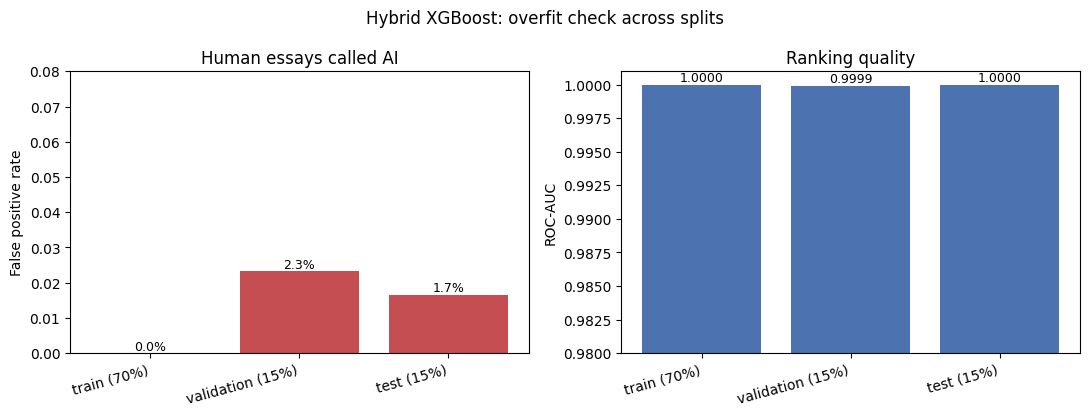

Wrote /workspace/hybrid-ai-framework/data/processed/models/hybrid_fit_check.png


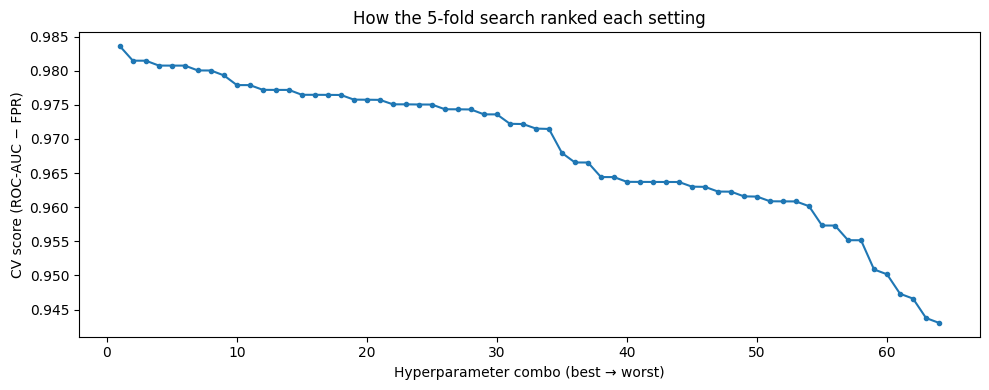

Wrote /workspace/hybrid-ai-framework/data/processed/models/hybrid_cv_search.png


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

splits = fit_table["split"].tolist()
x = range(len(splits))

axes[0].bar(x, fit_table["fpr"], color="#c44e52")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(splits, rotation=15, ha="right")
axes[0].set_ylabel("False positive rate")
axes[0].set_title("Human essays called AI")
axes[0].set_ylim(0, max(0.08, fit_table["fpr"].max() * 1.4))
for i, v in enumerate(fit_table["fpr"]):
    axes[0].text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

axes[1].bar(x, fit_table["roc_auc"], color="#4c72b0")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(splits, rotation=15, ha="right")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Ranking quality")
axes[1].set_ylim(0.98, 1.001)
for i, v in enumerate(fit_table["roc_auc"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Hybrid XGBoost: overfit check across splits")
fig.tight_layout()
fig_path = MODELS_DIR / "hybrid_fit_check.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Wrote", fig_path)

# Grid-search scores if this kernel still has `search` from training.
if "search" in globals():
    cv_plot = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False)
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    ax2.plot(range(1, len(cv_plot) + 1), cv_plot["mean_test_score"].to_numpy(), marker="o", ms=3)
    ax2.set_xlabel("Hyperparameter combo (best → worst)")
    ax2.set_ylabel("CV score (ROC-AUC − FPR)")
    ax2.set_title("How the 5-fold search ranked each setting")
    fig2.tight_layout()
    cv_fig = MODELS_DIR / "hybrid_cv_search.png"
    fig2.savefig(cv_fig, dpi=150, bbox_inches="tight")
    plt.show()
    print("Wrote", cv_fig)
